
# Gabor bank: where image energy and image details go

This notebook answers two different questions on a **real image**:

1. **Where does the image energy go?**
2. **Where do the image details go?**

We keep these two ideas separate.

- The **image energy** is the usual quantity
  $$
  E_{\text{image}} = \sum_{x,y} I(x,y)^2.
  $$
- The **detail image** is obtained by subtracting a low-pass version:
  $$
  I_{\text{detail}} = I - I_{\text{low-pass}}.
  $$
- For each Gabor channel $(\theta,f)$, we measure the **mean squared magnitude**
  $$
  E_{\theta,f} = \operatorname{mean}\bigl(|R_{\theta,f}|^2\bigr),
  $$
  where $R_{\theta,f}$ is the complex Gabor response.

Important: this notebook uses a **small normalized Gabor bank** for analysis.  
It is **not** a Parseval-tight frame, so the sum of channel energies is **not** expected to equal the full image energy.


In [2]:

import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage as ndi
from skimage import data, img_as_float
from skimage.filters import gabor_kernel, gaussian
from skimage.transform import resize


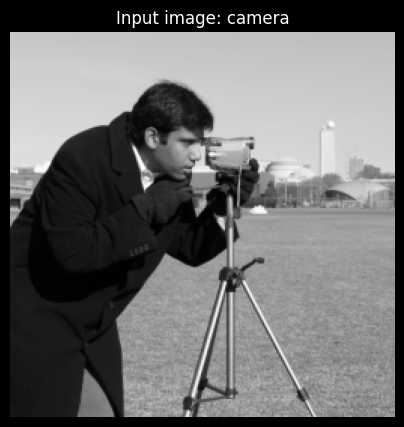

shape: (256, 256)
intensity range: (0.008465512696419247, 0.9994933599059728)


In [3]:

# ------------------------------------------------------------
# Choose a real image here: "camera" or "brick"
# ------------------------------------------------------------
image_name = "camera"   # change to "brick" if you want
max_size = 256           # keeps the notebook fast and readable

if image_name == "camera":
    img = img_as_float(data.camera())
elif image_name == "brick":
    img = img_as_float(data.brick())
else:
    raise ValueError("image_name must be 'camera' or 'brick'")

if img.ndim == 3:
    img = img.mean(axis=2)

if max(img.shape) > max_size:
    scale = max_size / max(img.shape)
    new_shape = (int(round(img.shape[0] * scale)), int(round(img.shape[1] * scale)))
    img = resize(img, new_shape, anti_aliasing=True)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img, cmap="gray")
ax.set_title(f"Input image: {image_name}")
ax.axis("off")
plt.show()

print("shape:", img.shape)
print("intensity range:", (float(img.min()), float(img.max())))



## Low-pass part versus detail part

At zero frequency, the orientation $\theta$ has no meaning:

$$
e^{i 2\pi f x_\theta} = 1 \quad \text{when } f=0.
$$

So we treat the zero-frequency content separately with a **low-pass channel**, then we use the Gabor bank for the **band-pass oriented** content.

This gives a clean split:

$$
I = I_{\text{low-pass}} + I_{\text{detail}}.
$$

The detail image is not "all the information," but it is a good practical proxy for **fine structure and texture**.


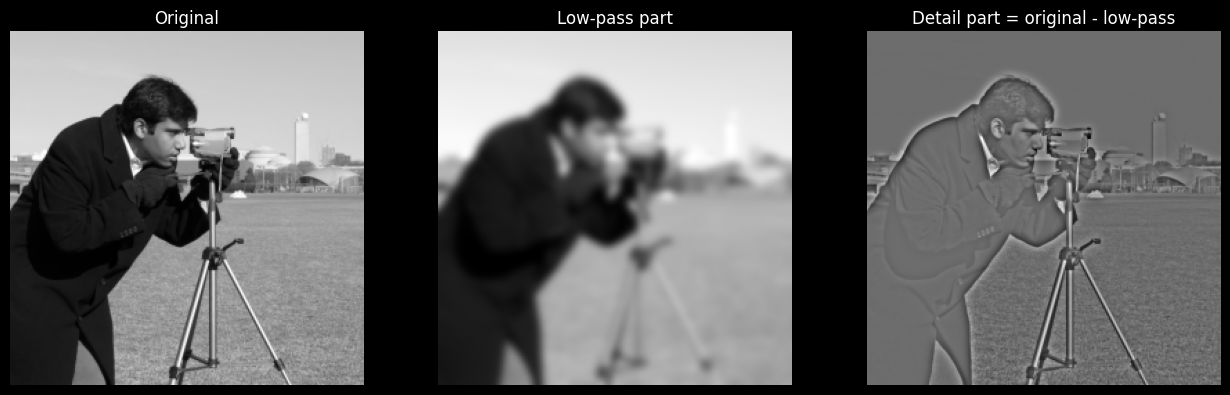

IMAGE / LOW-PASS / DETAIL ENERGIES
total image energy    = 22131.338823
total low-pass energy = 21571.012799  (97.47% of image energy)
total detail energy   = 304.268951  ( 1.37% of image energy)


In [4]:

# ------------------------------------------------------------
# Low-pass / detail split
# ------------------------------------------------------------
lowpass_sigma = 3.0
lowpass = gaussian(img, sigma=lowpass_sigma, preserve_range=True)
detail = img - lowpass

image_energy_total = np.sum(img**2)
lowpass_energy_total = np.sum(lowpass**2)
detail_energy_total = np.sum(detail**2)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(lowpass, cmap="gray")
axes[1].set_title("Low-pass part")
axes[1].axis("off")

axes[2].imshow(detail, cmap="gray")
axes[2].set_title("Detail part = original - low-pass")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("IMAGE / LOW-PASS / DETAIL ENERGIES")
print(f"total image energy    = {image_energy_total:.6f}")
print(f"total low-pass energy = {lowpass_energy_total:.6f}  ({100*lowpass_energy_total/image_energy_total:5.2f}% of image energy)")
print(f"total detail energy   = {detail_energy_total:.6f}  ({100*detail_energy_total/image_energy_total:5.2f}% of image energy)")



## A richer normalized Gabor bank

We use several frequencies and orientations, and we normalize each complex Gabor kernel to unit $L^2$ norm before filtering.

This does **not** make the bank Parseval-tight, but it makes channel comparisons much fairer than an unnormalized bank.


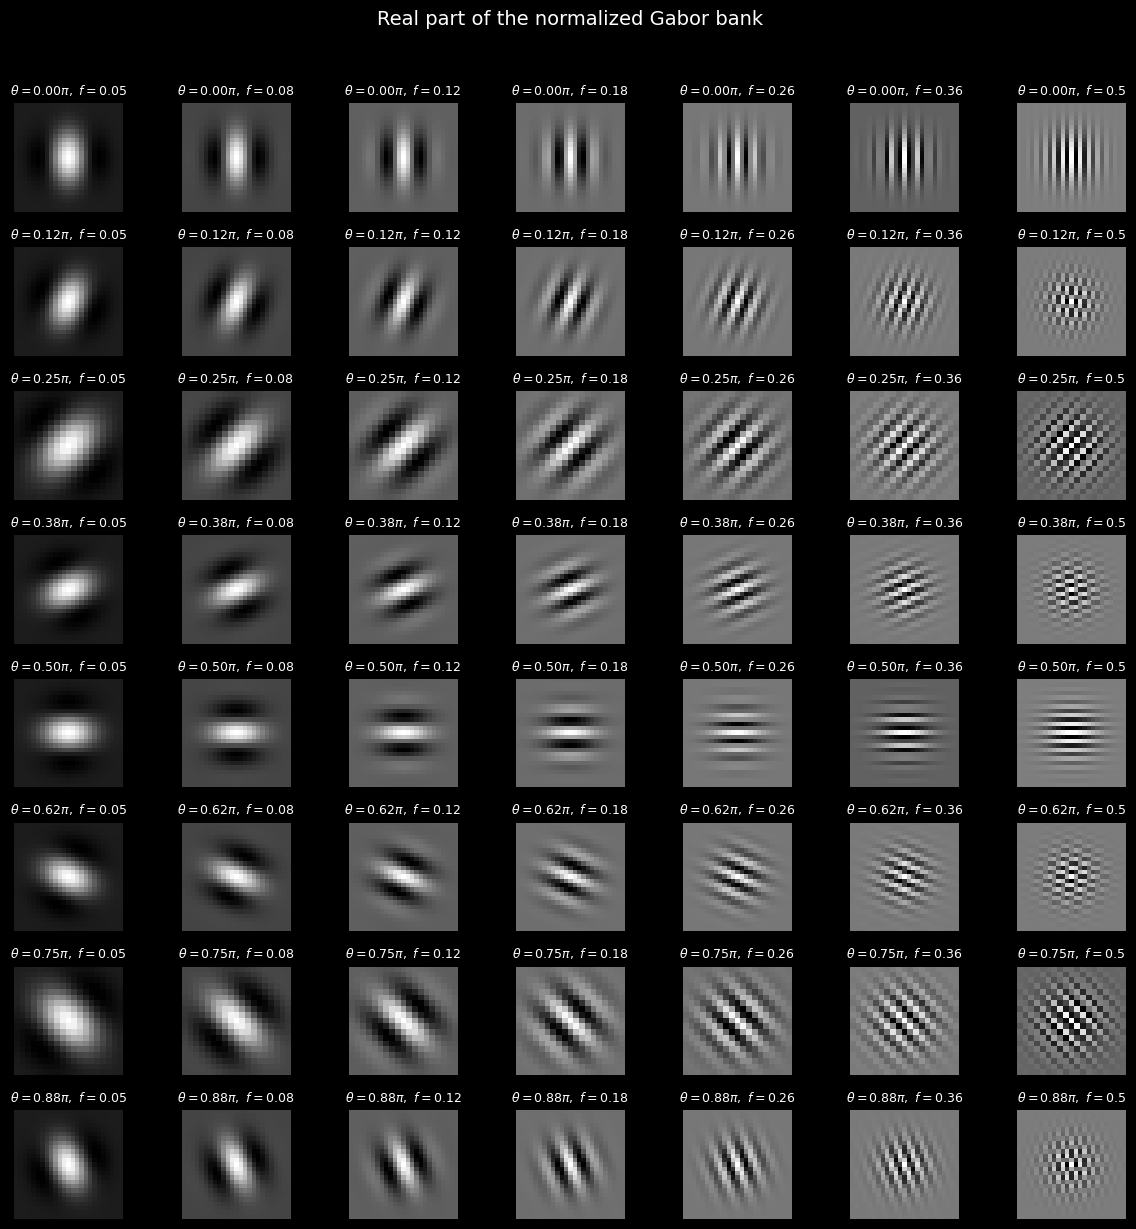

In [5]:

# ------------------------------------------------------------
# Normalized Gabor bank
# ------------------------------------------------------------
frequencies = [0.05, 0.08, 0.12, 0.18, 0.26, 0.36,0.5]
thetas = np.linspace(0, np.pi, 8, endpoint=False)
sigma_x = 4.0
sigma_y = 4.0

def normalized_gabor_response(image, frequency, theta, sigma_x=4.0, sigma_y=4.0):
    kernel = gabor_kernel(frequency=frequency, theta=theta, sigma_x=sigma_x, sigma_y=sigma_y)
    kernel = kernel / np.sqrt(np.sum(np.abs(kernel)**2))
    real = ndi.convolve(image, np.real(kernel), mode="reflect")
    imag = ndi.convolve(image, np.imag(kernel), mode="reflect")
    return real, imag, kernel

# Show the real part of a few kernels
fig, axes = plt.subplots(len(thetas), len(frequencies), figsize=(12, 12))
for i, theta in enumerate(thetas):
    for j, freq in enumerate(frequencies):
        _, _, kernel = normalized_gabor_response(img, frequency=freq, theta=theta, sigma_x=sigma_x, sigma_y=sigma_y)
        axes[i, j].imshow(np.real(kernel), cmap="gray")
        axes[i, j].set_title(fr"$\theta={theta/np.pi:.2f}\pi,\ f={freq}$", fontsize=9)
        axes[i, j].axis("off")

plt.suptitle("Real part of the normalized Gabor bank", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [6]:

# ------------------------------------------------------------
# Channel energies on the original image and on the detail image
# ------------------------------------------------------------
energy_orig = np.zeros((len(thetas), len(frequencies)))
energy_detail = np.zeros_like(energy_orig)
response_maps_orig = {}
response_maps_detail = {}

for i, theta in enumerate(thetas):
    for j, freq in enumerate(frequencies):
        real_o, imag_o, _ = normalized_gabor_response(img, frequency=freq, theta=theta, sigma_x=sigma_x, sigma_y=sigma_y)
        mag_sq_o = real_o**2 + imag_o**2
        energy_orig[i, j] = mag_sq_o.mean()
        response_maps_orig[(i, j)] = mag_sq_o

        real_d, imag_d, _ = normalized_gabor_response(detail, frequency=freq, theta=theta, sigma_x=sigma_x, sigma_y=sigma_y)
        mag_sq_d = real_d**2 + imag_d**2
        energy_detail[i, j] = mag_sq_d.mean()
        response_maps_detail[(i, j)] = mag_sq_d

bank_energy_orig = energy_orig.sum()
bank_energy_detail = energy_detail.sum()

energy_by_freq_orig = energy_orig.sum(axis=0)
energy_by_theta_orig = energy_orig.sum(axis=1)
energy_by_freq_detail = energy_detail.sum(axis=0)
energy_by_theta_detail = energy_detail.sum(axis=1)

channels_orig = []
channels_detail = []
for i, theta in enumerate(thetas):
    for j, freq in enumerate(frequencies):
        channels_orig.append((theta, freq, energy_orig[i, j], i, j))
        channels_detail.append((theta, freq, energy_detail[i, j], i, j))

channels_orig = sorted(channels_orig, key=lambda x: x[2], reverse=True)
channels_detail = sorted(channels_detail, key=lambda x: x[2], reverse=True)


In [7]:
# ------------------------------------------------------------
# Print where the energy goes and where the details go
# ------------------------------------------------------------
print("ORIGINAL IMAGE -> GABOR BANK")
print(f"sum of channel mean energies = {bank_energy_orig:.6f}\n")
print("Energy grouped by frequency (original image):")
for freq, E in zip(frequencies, energy_by_freq_orig):
    print(f"frequency = {freq:>4.2f} -> {E:.6f}  ({100*E/bank_energy_orig:5.2f}%)")

print("\nEnergy grouped by orientation (original image):")
for theta, E in zip(thetas, energy_by_theta_orig):
    print(f"theta = {theta/np.pi:.2f}π -> {E:.6f}  ({100*E/bank_energy_orig:5.2f}%)")

print("\nTop 8 original-image channels:")
for theta, freq, E, _, _ in channels_orig[:8]:
    print(f"theta = {theta/np.pi:.2f}π, frequency = {freq:.2f}, mean energy = {E:.6f}, share = {100*E/bank_energy_orig:5.2f}%")

print("\n" + "-"*72 + "\n")

print("DETAIL IMAGE -> GABOR BANK")
print(f"sum of channel mean energies = {bank_energy_detail:.6f}\n")
print("Energy grouped by frequency (detail image):")
for freq, E in zip(frequencies, energy_by_freq_detail):
    print(f"frequency = {freq:>4.2f} -> {E:.6f}  ({100*E/bank_energy_detail:5.2f}%)")

print("\nEnergy grouped by orientation (detail image):")
for theta, E in zip(thetas, energy_by_theta_detail):
    print(f"theta = {theta/np.pi:.2f}π -> {E:.6f}  ({100*E/bank_energy_detail:5.2f}%)")

print("\nTop 8 detail-image channels:")
for theta, freq, E, _, _ in channels_detail[:8]:
    print(f"theta = {theta/np.pi:.2f}π, frequency = {freq:.2f}, mean energy = {E:.6f}, share = {100*E/bank_energy_detail:5.2f}%")


ORIGINAL IMAGE -> GABOR BANK
sum of channel mean energies = 124.828105

Energy grouped by frequency (original image):
frequency = 0.05 -> 113.475571  (90.91%)
frequency = 0.08 -> 10.747453  ( 8.61%)
frequency = 0.12 -> 0.420710  ( 0.34%)
frequency = 0.18 -> 0.125853  ( 0.10%)
frequency = 0.26 -> 0.043628  ( 0.03%)
frequency = 0.36 -> 0.010788  ( 0.01%)
frequency = 0.50 -> 0.004102  ( 0.00%)

Energy grouped by orientation (original image):
theta = 0.00π -> 15.328107  (12.28%)
theta = 0.12π -> 15.456348  (12.38%)
theta = 0.25π -> 16.565366  (13.27%)
theta = 0.38π -> 15.363216  (12.31%)
theta = 0.50π -> 15.212820  (12.19%)
theta = 0.62π -> 15.219238  (12.19%)
theta = 0.75π -> 16.367649  (13.11%)
theta = 0.88π -> 15.315361  (12.27%)

Top 8 original-image channels:
theta = 0.25π, frequency = 0.05, mean energy = 14.992148, share = 12.01%
theta = 0.75π, frequency = 0.05, mean energy = 14.862227, share = 11.91%
theta = 0.12π, frequency = 0.05, mean energy = 14.017650, share = 11.23%
theta = 0.

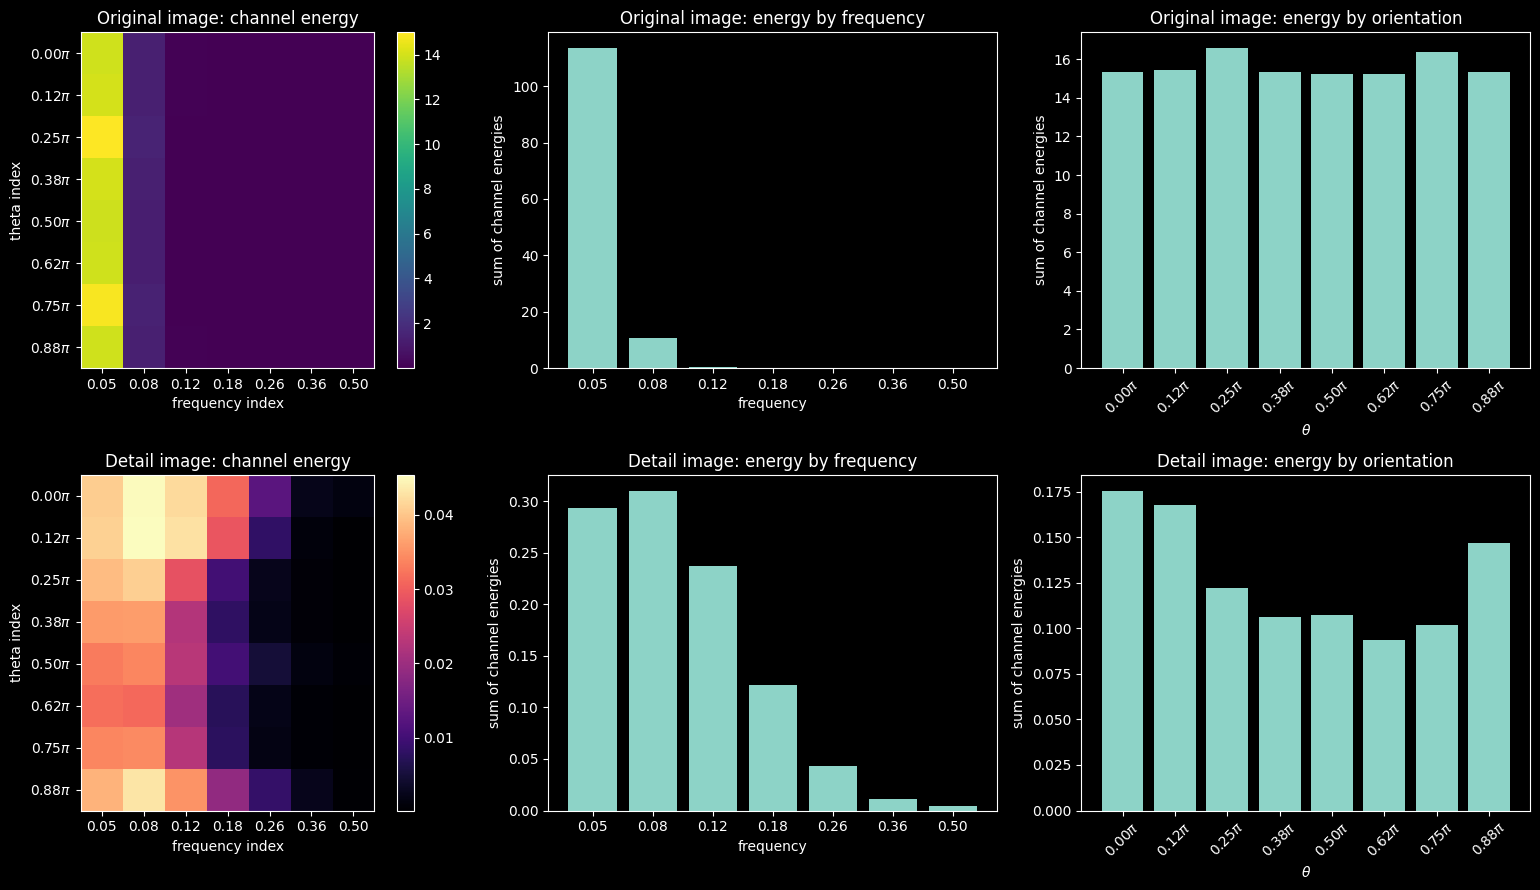

In [8]:

# ------------------------------------------------------------
# Plots: energy flow across frequency and orientation
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

im0 = axes[0, 0].imshow(energy_orig, cmap="viridis")
axes[0, 0].set_title("Original image: channel energy")
axes[0, 0].set_xlabel("frequency index")
axes[0, 0].set_ylabel("theta index")
axes[0, 0].set_xticks(range(len(frequencies)))
axes[0, 0].set_xticklabels([f"{f:.2f}" for f in frequencies])
axes[0, 0].set_yticks(range(len(thetas)))
axes[0, 0].set_yticklabels([fr"{th/np.pi:.2f}$\pi$" for th in thetas])
plt.colorbar(im0, ax=axes[0, 0])

axes[0, 1].bar(range(len(frequencies)), energy_by_freq_orig)
axes[0, 1].set_title("Original image: energy by frequency")
axes[0, 1].set_xlabel("frequency")
axes[0, 1].set_ylabel("sum of channel energies")
axes[0, 1].set_xticks(range(len(frequencies)))
axes[0, 1].set_xticklabels([f"{f:.2f}" for f in frequencies])

axes[0, 2].bar(range(len(thetas)), energy_by_theta_orig)
axes[0, 2].set_title("Original image: energy by orientation")
axes[0, 2].set_xlabel(r"$\theta$")
axes[0, 2].set_ylabel("sum of channel energies")
axes[0, 2].set_xticks(range(len(thetas)))
axes[0, 2].set_xticklabels([fr"{th/np.pi:.2f}$\pi$" for th in thetas], rotation=45)

im1 = axes[1, 0].imshow(energy_detail, cmap="magma")
axes[1, 0].set_title("Detail image: channel energy")
axes[1, 0].set_xlabel("frequency index")
axes[1, 0].set_ylabel("theta index")
axes[1, 0].set_xticks(range(len(frequencies)))
axes[1, 0].set_xticklabels([f"{f:.2f}" for f in frequencies])
axes[1, 0].set_yticks(range(len(thetas)))
axes[1, 0].set_yticklabels([fr"{th/np.pi:.2f}$\pi$" for th in thetas])
plt.colorbar(im1, ax=axes[1, 0])

axes[1, 1].bar(range(len(frequencies)), energy_by_freq_detail)
axes[1, 1].set_title("Detail image: energy by frequency")
axes[1, 1].set_xlabel("frequency")
axes[1, 1].set_ylabel("sum of channel energies")
axes[1, 1].set_xticks(range(len(frequencies)))
axes[1, 1].set_xticklabels([f"{f:.2f}" for f in frequencies])

axes[1, 2].bar(range(len(thetas)), energy_by_theta_detail)
axes[1, 2].set_title("Detail image: energy by orientation")
axes[1, 2].set_xlabel(r"$\theta$")
axes[1, 2].set_ylabel("sum of channel energies")
axes[1, 2].set_xticks(range(len(thetas)))
axes[1, 2].set_xticklabels([fr"{th/np.pi:.2f}$\pi$" for th in thetas], rotation=45)

plt.tight_layout()
plt.show()


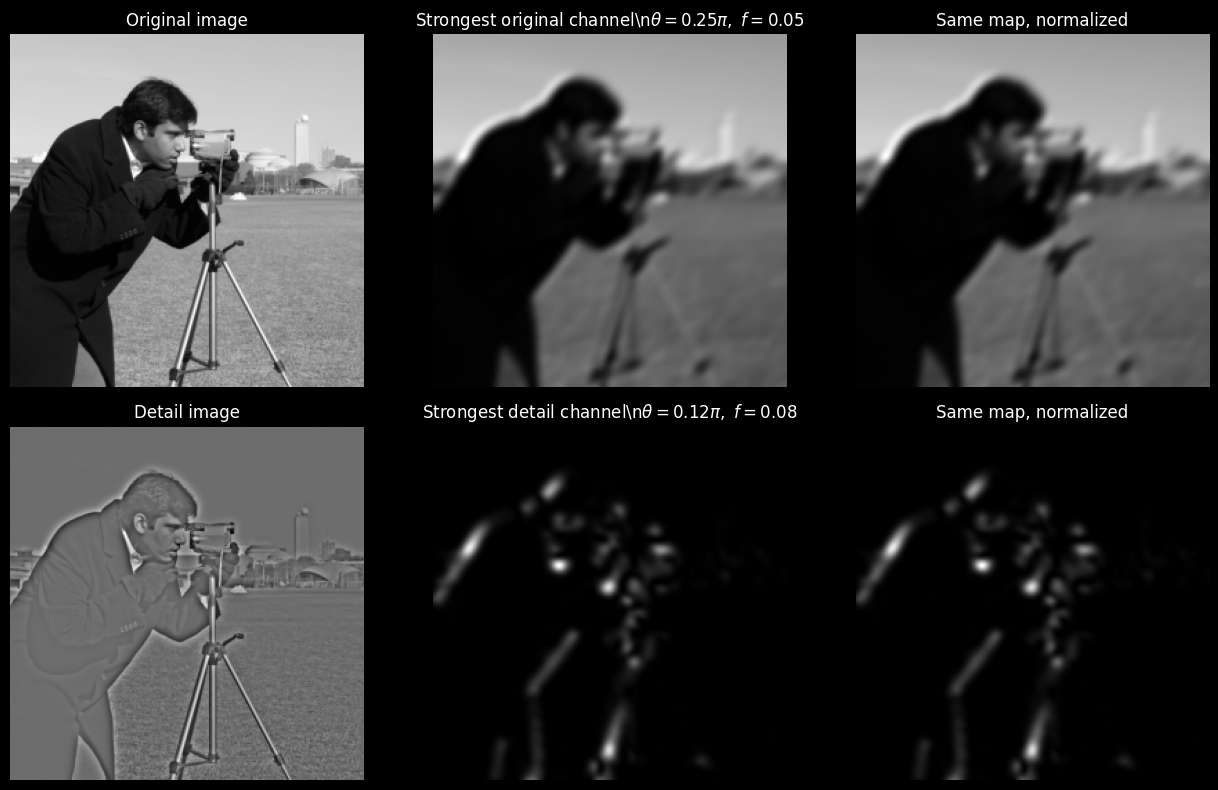

In [9]:
# ------------------------------------------------------------
# Show the strongest channels for coarse content and detail content
# ------------------------------------------------------------
(top_theta_o, top_freq_o, _, i_o, j_o) = channels_orig[0]
(top_theta_d, top_freq_d, _, i_d, j_d) = channels_detail[0]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

axes[0, 0].imshow(img, cmap="gray")
axes[0, 0].set_title("Original image")
axes[0, 0].axis("off")

axes[0, 1].imshow(response_maps_orig[(i_o, j_o)], cmap="gray")
axes[0, 1].set_title(fr"Strongest original channel\n$\theta={top_theta_o/np.pi:.2f}\pi,\ f={top_freq_o}$")
axes[0, 1].axis("off")

axes[0, 2].imshow(response_maps_orig[(i_o, j_o)] / response_maps_orig[(i_o, j_o)].max(), cmap="gray")
axes[0, 2].set_title("Same map, normalized")
axes[0, 2].axis("off")

axes[1, 0].imshow(detail, cmap="gray")
axes[1, 0].set_title("Detail image")
axes[1, 0].axis("off")

axes[1, 1].imshow(response_maps_detail[(i_d, j_d)], cmap="gray")
axes[1, 1].set_title(fr"Strongest detail channel\n$\theta={top_theta_d/np.pi:.2f}\pi,\ f={top_freq_d}$")
axes[1, 1].axis("off")

axes[1, 2].imshow(response_maps_detail[(i_d, j_d)] / response_maps_detail[(i_d, j_d)].max(), cmap="gray")
axes[1, 2].set_title("Same map, normalized")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()



## How to read the results

- The **original-image bank energy** is usually dominated by low frequencies, because natural images contain lots of coarse structure.
- The **detail-image bank energy** is more relevant when you want to know where texture and fine structure go.
- If the detail-image energy shifts toward mid or high frequencies, then the bank is capturing genuinely finer content.
- If even the detail-image energy stays almost entirely in the lowest frequencies, then the bank is still too coarse for that image.

So the right question is not only **"how much total bank energy is there?"**  
It is also **"in which channels does the detail image place its energy?"**
